## 🔍 Combined EDA for Banking Risk Analysis
This notebook merges insights and code from two original EDA versions. Key cleaning, exploratory, and analytical steps are documented with comments.

## 🧼 Data Audit & Validation

Before performing Exploratory Data Analysis (EDA) or modeling, it's essential to confirm that the dataset is clean and reliable. This section documents the data quality checks performed on the raw dataset.


In [2]:
# Load dataset from local machine (CSV format)
import pandas as pd

df = pd.read_csv("Banking.csv")

# Convert 'Joined Bank' to datetime
df['Joined Bank'] = pd.to_datetime(df['Joined Bank'], dayfirst=True)

# Preview dataset
df.head()


,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [3]:
df['Joined Bank'].dtype


dtype('<M8[ns]')

In [4]:
import os

folder_path = r"C:\Users\MinaS\OneDrive\Graduation Project\Banking-20250428T234930Z-001"
print("Files in directory:")
print(os.listdir(folder_path))


Files in directory:
['Banking']


### ✅ Conclusion

- **No missing values** were found in any column.
- **No duplicate rows** were detected.
- **All columns have appropriate data types** for further analysis and modeling.
- This confirms the dataset is **clean and ready for use**.

This audit ensures that subsequent steps are built on a valid and trustworthy dataset.


## Univariate Analysis

## Bivariate Analysis

## Numerical Analysis

## Heatmaps

## Insights of EDA:

1. The strongest positive correlation occur among "Bank Deposits" with "Checking Accounts", "Saving Accounts" and "Foreign Currency Account" indicating that customers who maintain high balances in one account type often hold substantial amount/funds across other accounts as well.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
# df = pd.read_csv('/content/Banking.csv')
# df.head(5)

In [7]:
df.shape

(3000, 25)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Client ID                 3000 non-null   object        
 1   Name                      3000 non-null   object        
 2   Age                       3000 non-null   int64         
 3   Location ID               3000 non-null   int64         
 4   Joined Bank               3000 non-null   datetime64[ns]
 5   Banking Contact           3000 non-null   object        
 6   Nationality               3000 non-null   object        
 7   Occupation                3000 non-null   object        
 8   Fee Structure             3000 non-null   object        
 9   Loyalty Classification    3000 non-null   object        
 10  Estimated Income          3000 non-null   float64       
 11  Superannuation Savings    3000 non-null   float64       
 12  Amount of Credit Car

In [9]:
# Generate descriptive statistics for the dataframe
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [10]:
bins = [0, 100000, 300000, float('inf')]
labels = ['Low', 'Med', 'High']

df['Income Band'] = pd.cut(df['Estimated Income'], bins=bins, labels=labels, right=False)

<AxesSubplot:>

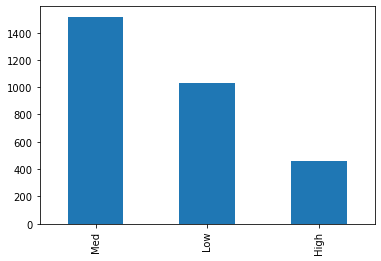

In [11]:
df['Income Band'].value_counts().plot(kind='bar')

In [12]:
# Examine the distribution of unique cataegories in categorical columns
categorical_cols = df[["BRId", "GenderId", "IAId", "Amount of Credit Cards", "Nationality", "Occupation", "Fee Structure", "Loyalty Classification", "Properties Owned", "Risk Weighting", "Income Band"]].columns

for col in categorical_cols:
  print(f"Value Counts for '{col}':")
  display(df[col].value_counts())

Value Counts for 'BRId':


3    1352
1     660
2     495
4     493
Name: BRId, dtype: int64

Value Counts for 'GenderId':


2    1512
1    1488
Name: GenderId, dtype: int64

Value Counts for 'IAId':


...

2    777
1    776
3    742
0    705
Name: Properties Owned, dtype: int64

Value Counts for 'Risk Weighting':


2    1222
1     836
3     460
4     322
5     160
Name: Risk Weighting, dtype: int64

Value Counts for 'Income Band':


Med     1517
Low     1027
High     456
Name: Income Band, dtype: int64

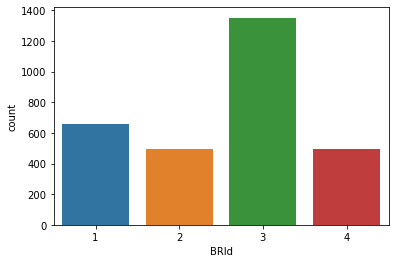

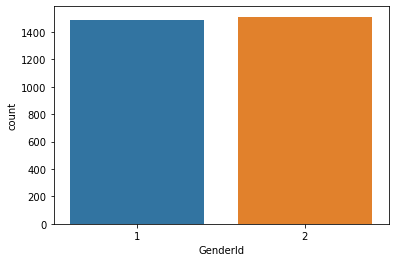

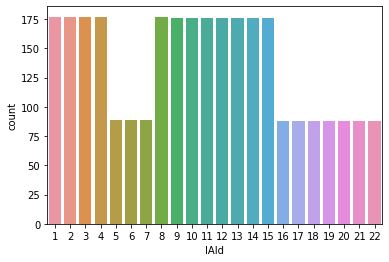

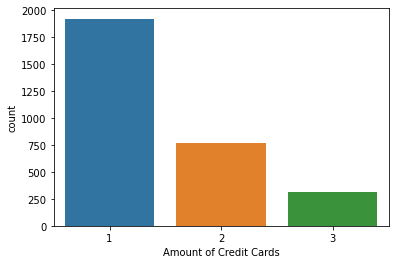

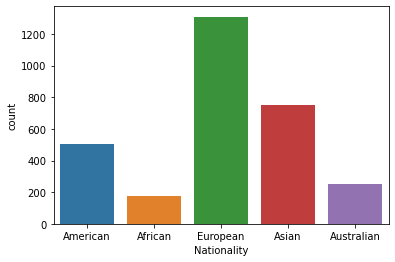

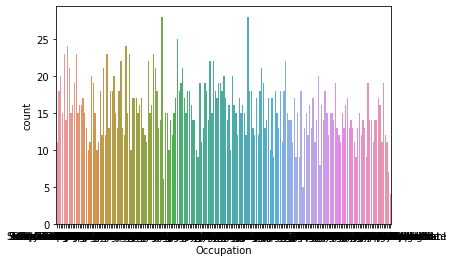

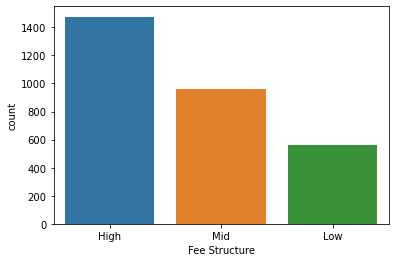

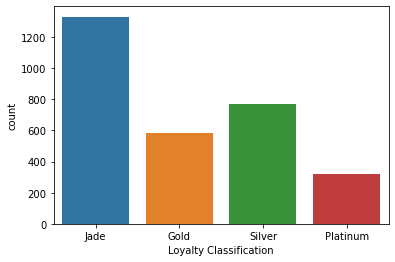

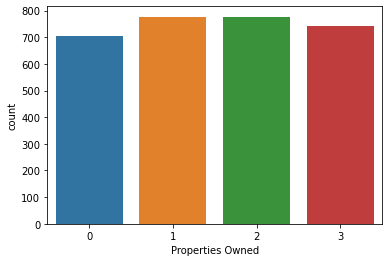

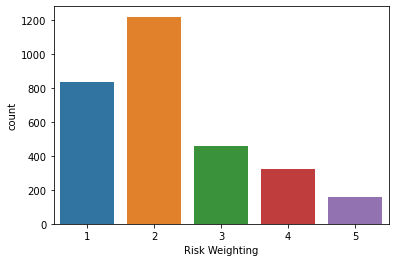

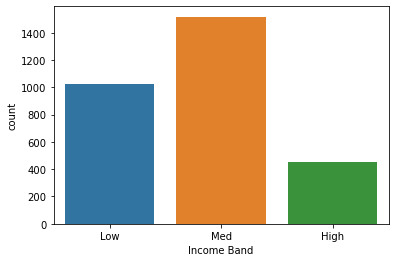

In [13]:
for i, predictor in enumerate(df[["BRId", "GenderId", "IAId", "Amount of Credit Cards", "Nationality", "Occupation", "Fee Structure", "Loyalty Classification", "Properties Owned", "Risk Weighting", "Income Band"]].columns):
    plt.figure(i)
    sns.countplot(data=df, x=predictor)

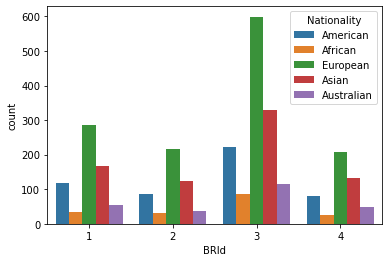

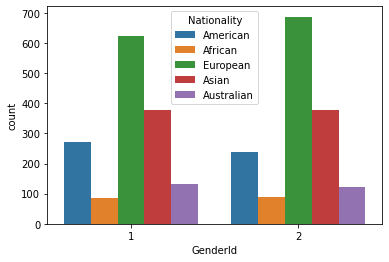

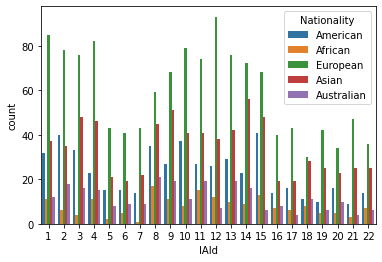

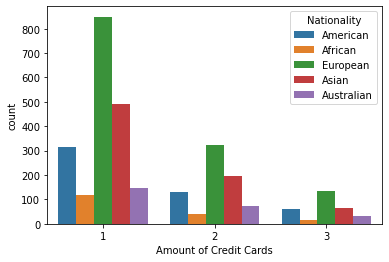

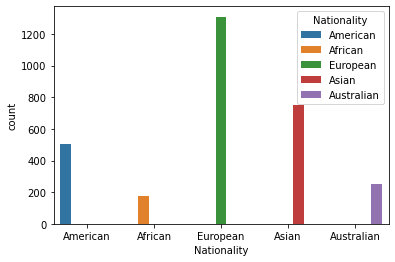

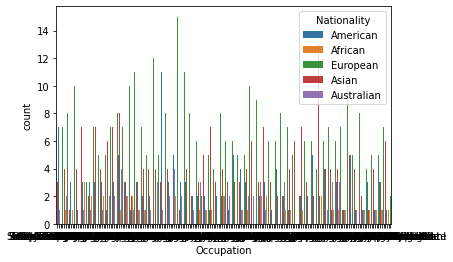

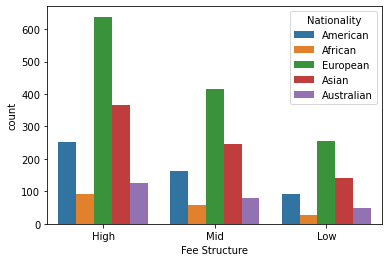

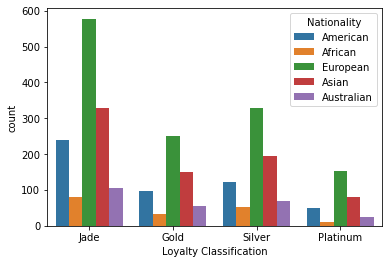

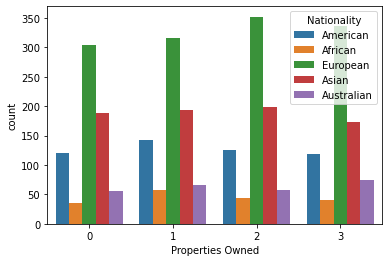

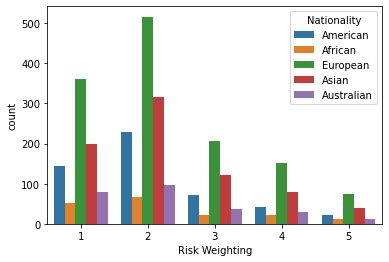

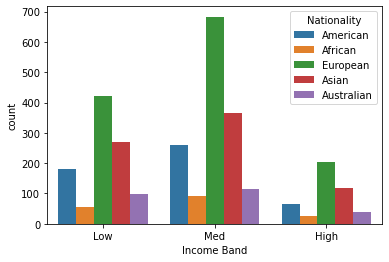

In [14]:
for i, predictor in enumerate(df[["BRId", "GenderId", "IAId", "Amount of Credit Cards", "Nationality", "Occupation", "Fee Structure", "Loyalty Classification", "Properties Owned", "Risk Weighting", "Income Band"]].columns):
    plt.figure(i)
    sns.countplot(data=df, x=predictor, hue='Nationality')

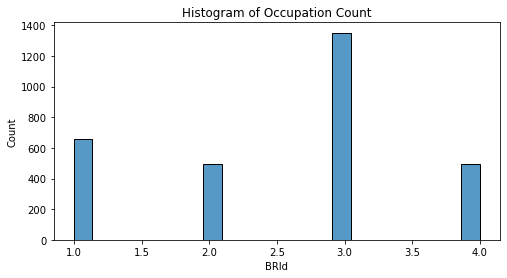

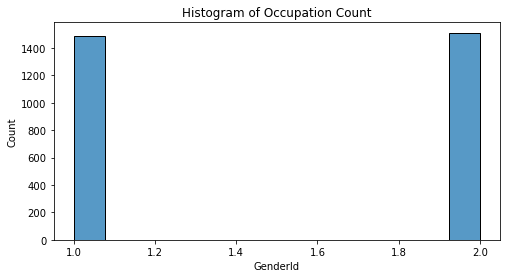

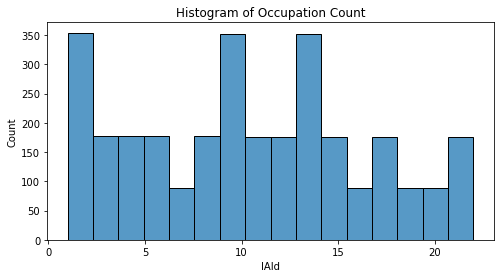

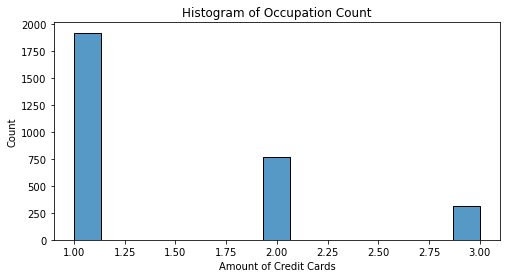

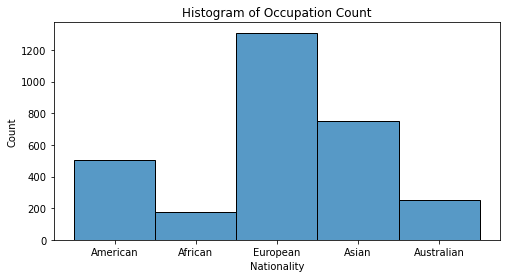

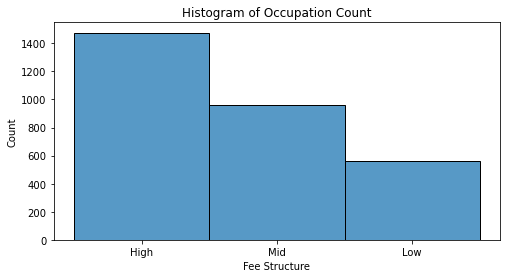

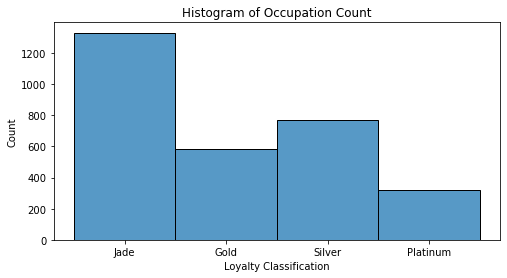

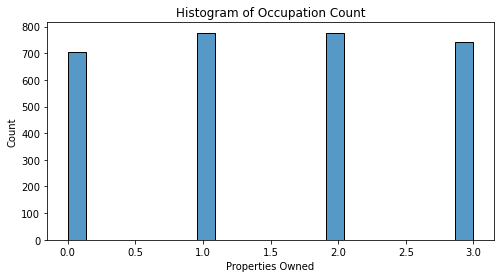

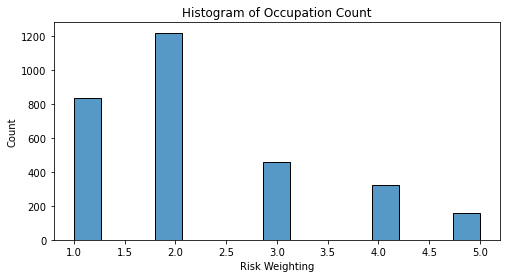

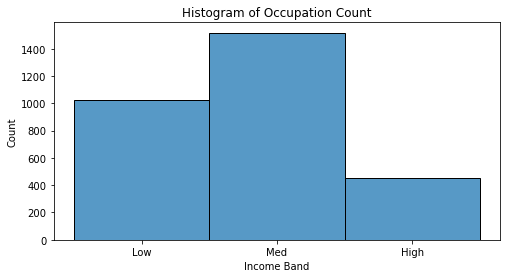

In [15]:
# HIstplot of value counts for different Occupation

for col in categorical_cols:
  if col == "Occupation":
    continue
  plt.figure(figsize=(8,4))
  sns.histplot(df[col])
  plt.title('Histogram of Occupation Count')
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.show()

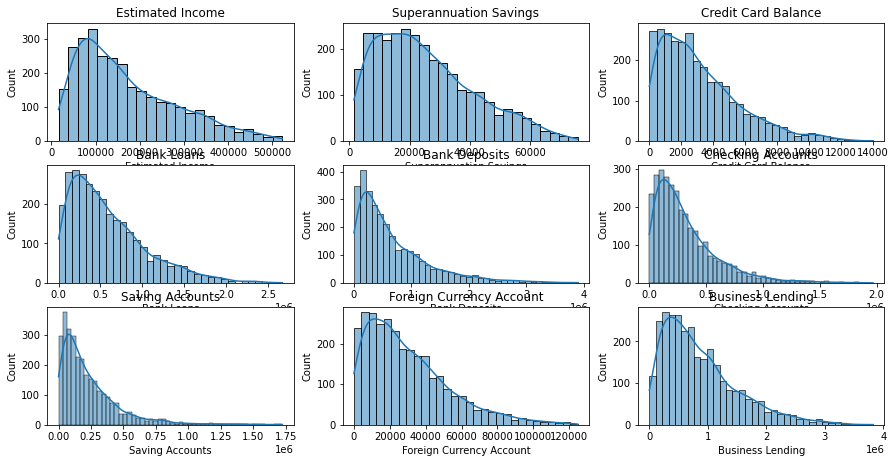

In [22]:
numerical_cols = ['Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

# Univariate analysis and visualization
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
  plt.subplot(4,3,i+1)
  sns.histplot(df[col],kde=True)
  plt.title(col)
plt.show()

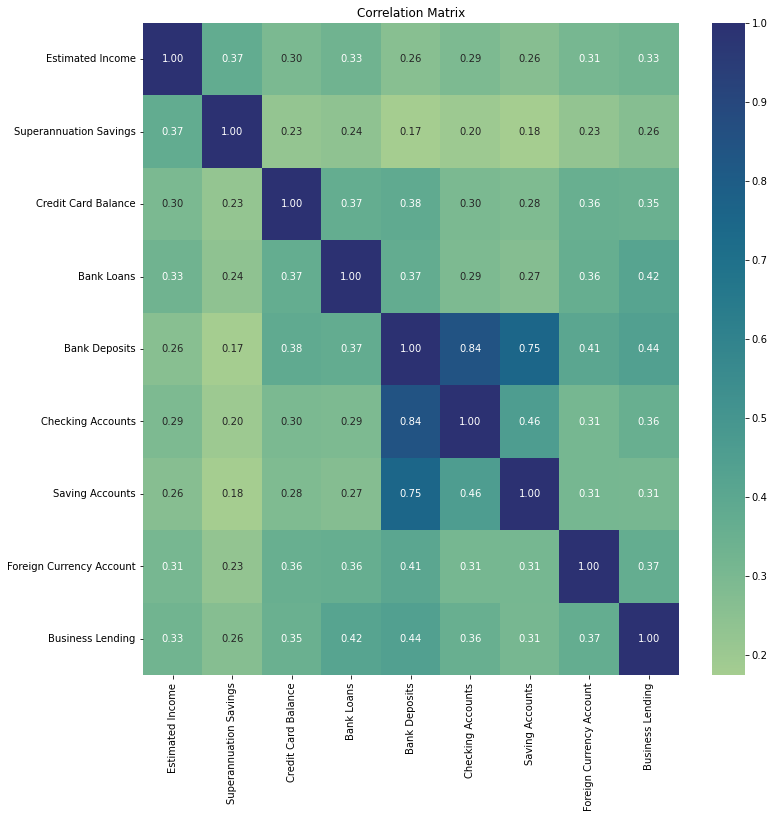

In [19]:
numerical_cols = ['Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12,12))
sns.heatmap(correlation_matrix, annot=True, cmap='crest', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## ➕ Additional Insights from Version 2

In [20]:
import pandas as pd
import numpy as np

In [21]:
df = pd.read_csv('Banking.csv')
df.head()

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [22]:
# Check the shape of the DataFrame
print("Shape of the DataFrame:", df.shape)

# Get a concise summary of the DataFrame
print("\nDataFrame Info:")
df.info()


Shape of the DataFrame: (3000, 25)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card

In [23]:
df["Estimated Income"]

0        75384.77
1       289834.31
2       169935.23
3       356808.11
4       130711.68
          ...    
2995    297617.14
2996     42397.46
2997     48339.88
2998    107265.87
2999     56826.53
Name: Estimated Income, Length: 3000, dtype: float64

In [24]:
# Define income band boundaries
bins = [0, 100000, 300000, float('inf')]
labels = ['Low', 'Mid', 'High']

# Create the 'Income Band' column using pd.cut
df['Income Band'] = pd.cut(df['Estimated Income'], bins=bins, labels=labels, include_lowest=True)

In [25]:

# Examine the distribution of unique categories in categorical columns
categorical_cols = df[["Risk Weighting","Nationality","Occupation","Fee Structure","Loyalty Classification","Properties Owned","Risk Weighting","Occupation","Income Band"]].columns
for col in categorical_cols:
  # if col in ["Client ID","Name","Joined Bank"]:
  #   continue
  print(f"\nValue Counts for '{col}':")
  display(df[col].value_counts())


Value Counts for 'Risk Weighting':


2    1222
1     836
3     460
4     322
5     160
Name: Risk Weighting, dtype: int64


Value Counts for 'Nationality':


European      1309
Asian          754
American       507
Australian     254
African        176
Name: Nationality, dtype: int64


Value Counts for 'Occupation':


...

2    1222
1     836
3     460
4     322
5     160
Name: Risk Weighting, dtype: int64


Value Counts for 'Occupation':


Structural Analysis Engineer    28
Associate Professor             28
Recruiter                       25
Human Resources Manager         24
Account Coordinator             24
                                ..
Office Assistant IV              8
Automation Specialist I          7
Computer Systems Analyst I       6
Developer III                    5
Senior Sales Associate           4
Name: Occupation, Length: 195, dtype: int64


Value Counts for 'Income Band':


Mid     1517
Low     1027
High     456
Name: Income Band, dtype: int64

In [26]:
# Generate descriptive statistics for numerical columns
print("\nDescriptive Statistics for Numerical Columns:")
display(df.describe())


Descriptive Statistics for Numerical Columns:


,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [27]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)


Missing values per column:
 Client ID                   0
Name                        0
Age                         0
Location ID                 0
Joined Bank                 0
Banking Contact             0
Nationality                 0
Occupation                  0
Fee Structure               0
Loyalty Classification      0
Estimated Income            0
Superannuation Savings      0
Amount of Credit Cards      0
Credit Card Balance         0
Bank Loans                  0
Bank Deposits               0
Checking Accounts           0
Saving Accounts             0
Foreign Currency Account    0
Business Lending            0
Properties Owned            0
Risk Weighting              0
BRId                        0
GenderId                    0
IAId                        0
Income Band                 0
dtype: int64


In [28]:
df['Joined Bank'] = pd.to_datetime(df['Joined Bank'], format='%d-%m-%Y')
print(df['Joined Bank'].dtype)

datetime64[ns]


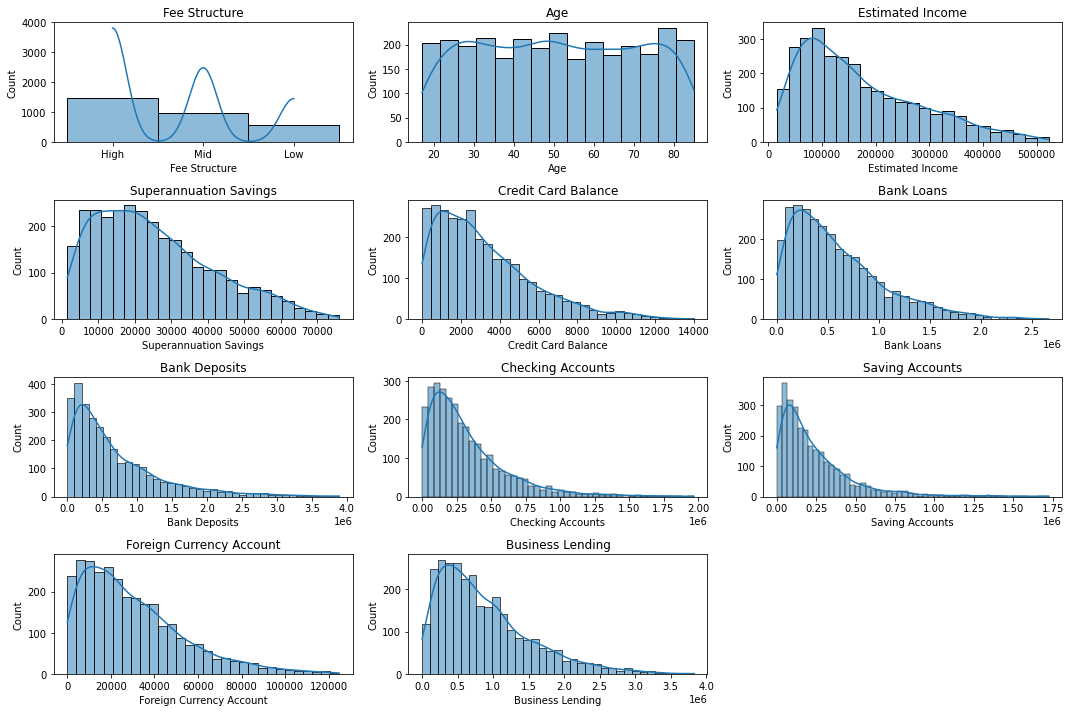

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical analysis and exploration
numerical_cols = ['Fee Structure','Age', 'Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

# Univariate analysis and visualization
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()



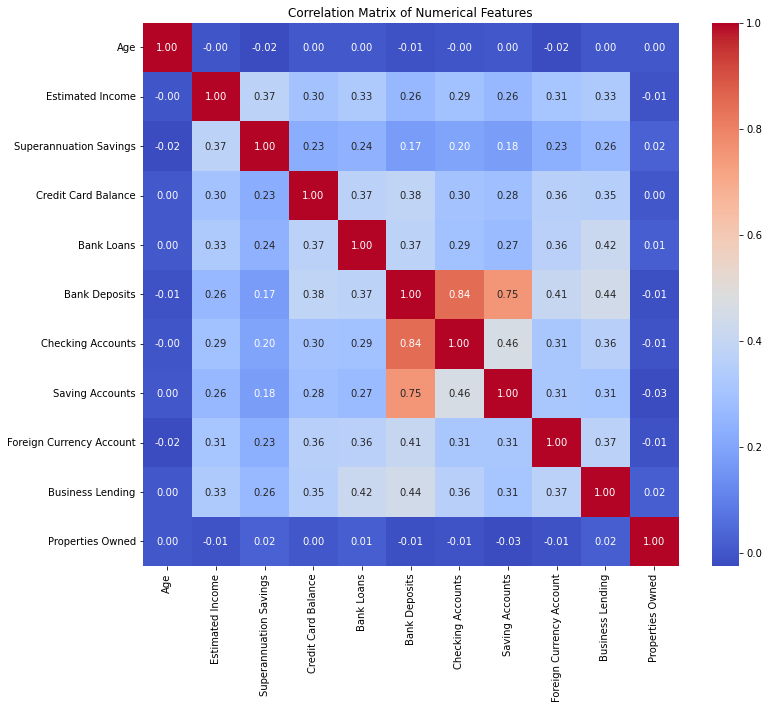

In [30]:
# Select numerical columns for correlation analysis
numerical_cols = ['Age', 'Estimated Income', 'Superannuation Savings', 'Credit Card Balance',
                  'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
                  'Foreign Currency Account', 'Business Lending', 'Properties Owned']

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

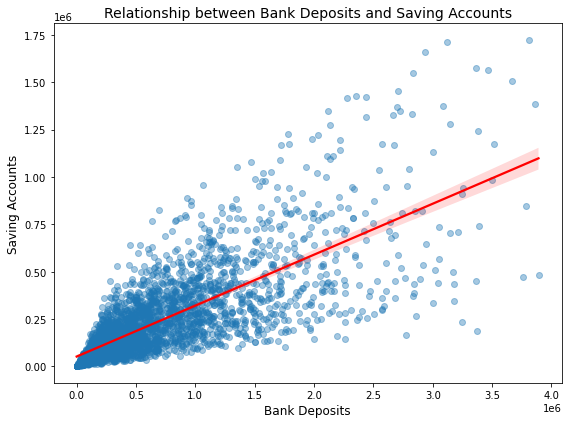

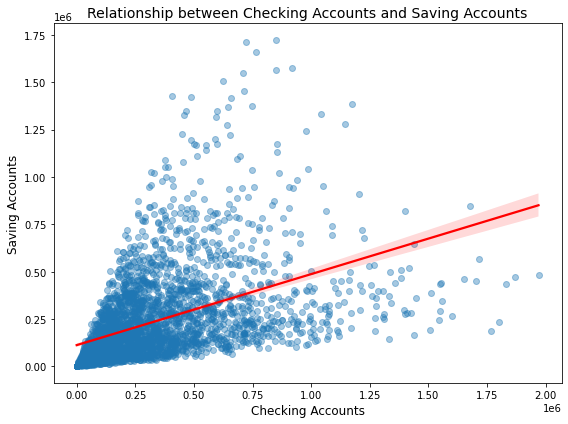

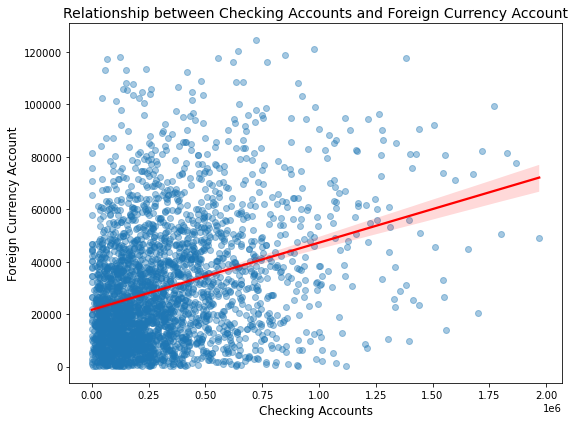

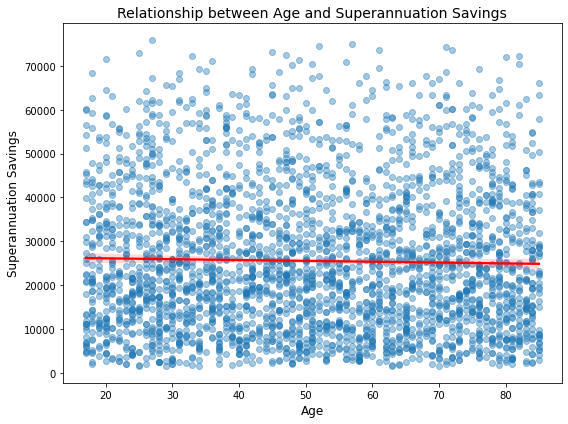

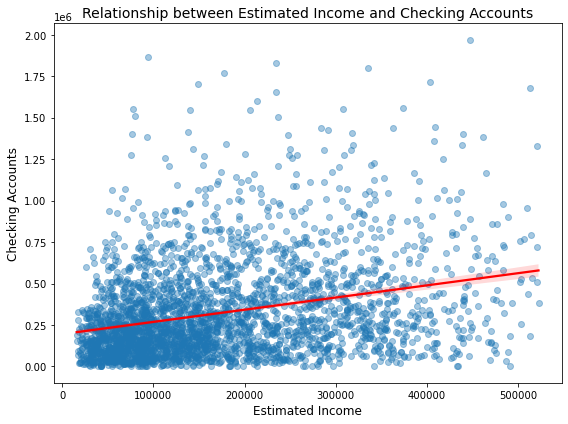

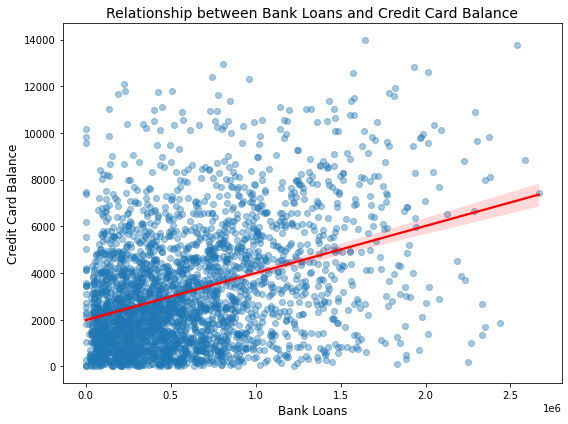

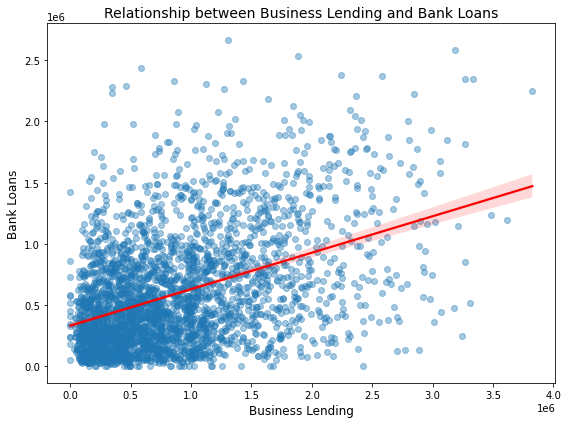

In [31]:
pairs_to_plot = [
    ('Bank Deposits', 'Saving Accounts'),
    ('Checking Accounts', 'Saving Accounts'),
    ('Checking Accounts', 'Foreign Currency Account'),
    ('Age', 'Superannuation Savings'),
    ('Estimated Income', 'Checking Accounts'),
    ('Bank Loans', 'Credit Card Balance'),
    ('Business Lending', 'Bank Loans'),
]


for x_col, y_col in pairs_to_plot:
    plt.figure(figsize=(8, 6))
    sns.regplot(
        data=df,
        x=x_col,
        y=y_col,
        scatter_kws={'alpha': 0.4},     # semi-transparent points
        line_kws={'color': 'red'}       # best-fit line color
    )
    plt.title(f'Relationship between {x_col} and {y_col}', fontsize=14)
    plt.xlabel(x_col, fontsize=12)
    plt.ylabel(y_col, fontsize=12)
    plt.tight_layout()
    plt.show()

## 📌 Summary of Key Insights
- Check for missing values, outliers, and skewed distributions.
- Understand customer segmentation based on risk.
- Prepare this EDA to feed into the LDA model.

This cleaned and annotated EDA will serve as a base for the modeling phase.

# Insights

## Income Band distribution:

### Income Band Calculation: After binning the "Estimated Income" into three categories ("Low," "Med," and "High"), we observe that the "Med" category has the highest count, indicating that most clients fall into the middle-income category.

### Implication: This suggests that the dataset has a significant number of moderate-income clients. In the context of financial risk analysis, this is important because moderate-income individuals may present a different risk profile compared to high- or low-income individuals.

## Banking Relationship distribution:

### Uneven Distribution of BRId Categories:

### Private bank dominates the chart significantly with more than 1200 clients.

### Retail comes next, showing a moderate frequency (between 500-600 clients).

### Institutional and commercial are the least frequent, with institutional having a count lower than retail but higher than commercial.

## Loyalty Classification distribution:

### Dominance of Jade Category:

### Jade has the highest frequency with over 1200 clients, significantly more than the other categories.

### This indicates that Jade is the most common loyalty classification, and it represents the majority of clients in the dataset.

### Balanced Representation of Gold and Silver Categories:

### Gold and Silver categories are more evenly distributed, with both showing a moderate count of clients.

### Gold is slightly less frequent than Silver, but their distribution is more balanced compared to Jade.

### Platinum Category is Least Frequent:

### Platinum is the least represented category, with a low number of clients. This could suggest that Platinum represents the most exclusive or highest-tier clients, which is typically a small group in many customer segments.

## Risk Weighting distribution: 

### High Frequency of Risk Weighting 2:

### Risk Weighting 2 has the highest frequency, with over 1200 clients in this category.

### This suggests that the majority of clients in the dataset are classified as moderate risk (Risk Weighting 2). This could reflect a typical trend in financial datasets where the majority of clients fall within a medium-risk category.

### Risk Weighting 1 and 3:

### Risk Weighting 1 (lowest risk) and Risk Weighting 3 (medium-high risk) show moderate frequencies.

### These categories may indicate lower and higher financial risk levels, with Risk Weighting 1 representing the least risky clients and Risk Weighting 3 representing more at-risk clients.

### Low Frequency of Extreme Risk Categories:

### Risk Weighting 4 and Risk Weighting 5 (highest risk) are the least frequent categories in the dataset.

### The relatively low count of clients in these categories suggests that the dataset contains fewer extreme cases of high-risk clients. This could imply that the financial institution has effective risk management or that high-risk clients are underrepresented.

## Nationality Distribution:

### Dominance of European Clients:

### European nationality has the highest frequency, with over 1200 clients in this category.

### This suggests that the dataset is heavily skewed towards European clients, potentially indicating that the data is more representative of clients from this region.

### Balanced Representation of Other Nationalities:

### American, Asian, and Australian nationalities show moderate distributions, with relatively similar frequencies across these categories.

### These categories seem to be somewhat equally represented, but all have lower counts than European clients.

### Low Frequency of African Clients:

### African nationality has the lowest frequency in the dataset.

## How nationalities are distributed across Risk Weighting categories:

### European nationality has the highest count in Risk Weighting 2, which suggests that Europeans are predominantly classified as lower-risk individuals compared to other nationalities. This could imply a financial profile that tends to be more stable, especially in terms of the dataset provided, where European clients could be perceived as having better financial stability or less risk.

### Asian nationality shows a more balanced distribution across different risk weighting categories, though it still has a higher concentration in Risk Weighting 2, similar to European clients. This suggests that Asian clients in the dataset also tend to have a relatively stable financial profile but exhibit more variability in terms of risk classification.

### American nationality is predominantly seen in Risk Weighting 2 and 3, indicating that most American clients have a moderate risk profile, with fewer in the higher or lower risk categories. This could imply that the American clients have a mix of higher income or wealth but also some variability in financial stability.

### African nationality has a high concentration in Risk Weighting 1 and 2, which means that many African clients are classified as either low or medium-risk. This could suggest that there are more financially stable clients in these groups or that these clients have a higher propensity to be classified as lower-risk.

### Australian nationality seems to be less represented, with Risk Weighting 1 and 2 being the dominant categories. However, since it has fewer data points overall, this distribution might be subject to the size of the group rather than representing any strong patterns of financial risk.

## Key takeaways:

### European clients tend to be more concentrated in the lower-risk categories, particularly Risk Weighting 2.

### Asian clients show more balance across categories but still prefer the lower-risk groups.

### American clients are spread across moderate-risk categories (Risk Weighting 2 and 3).

### African and Australian clients are mostly found in the lower-risk categories, with African clients in Risk Weighting 1 and 2.

#### Note: The distribution here highlights that nationality plays a role in how clients are classified in terms of financial risk.

## Insights from the correlation matrix:

### 1. Strong Correlation Between Bank Deposits and Bank Loans:
#### The correlation coefficient between Bank Deposits and Bank Loans is 0.84. This strong positive correlation indicates that clients who deposit more money into their bank accounts are likely to have higher loan balances. This could suggest that clients with greater financial stability (as reflected in their bank deposits) may also take on higher levels of credit, or they could be more trusted by financial institutions to receive loans.

### 2. Strong Positive Correlation Between Bank Deposits and Saving Accounts:
#### There is a 0.75 correlation between Bank Deposits and Saving Accounts. This suggests that clients who maintain high bank deposits are likely to also have a significant amount saved in savings accounts. This reinforces the idea that these two features are often reflective of financial stability and wealth.

### 3. Moderate to Strong Correlations Between Bank Accounts:
#### Checking Accounts and Saving Accounts are strongly correlated with Bank Deposits and each other, as seen with 0.84 between Checking Accounts and Bank Deposits, and 0.75 between Saving Accounts and Bank Deposits. 
#### This suggests that the financial activities of clients with checking and savings accounts are highly related to the amounts they deposit into their bank accounts. These accounts are integral in understanding the client’s financial position.

### 4. Superannuation Savings and Bank Accounts:
#### Superannuation Savings shows moderate positive correlations with Credit Card Balance (0.30), Bank Loans (0.24), and Bank Deposits (0.17). These are weaker relationships, indicating that while clients with superannuation savings may also use credit cards or take loans, this connection isn’t as strong as with other variables.

### 5. Credit Card Balance and Bank Loans:
#### Credit Card Balance and Bank Loans (0.38) show a moderate correlation, indicating some relationship, but not a very strong one. Clients with higher credit card balances are somewhat more likely to have loans, but it's not a definitive or powerful correlation.

### 6. Foreign Currency Accounts and Business Lending:
#### Foreign Currency Accounts and Business Lending (0.37) show a weak to moderate correlation, suggesting that clients with foreign currency accounts might be a bit more likely to be involved in business lending, but again, the relationship is not particularly strong.

## Key Takeaways:
### Bank Deposits and Bank Loans have a significant relationship, suggesting that clients with higher deposits are likely to take on higher loans.

### Bank Accounts, including both Checking Accounts and Saving Accounts, are strongly related to Bank Deposits, implying that clients with these accounts tend to have substantial financial deposits.

### Superannuation Savings is positively correlated but weakly so with other features, suggesting its role in clients' financial behavior might be secondary to more direct accounts like savings or checking.

### Credit Card Balance and Bank Loans show a moderate correlation, indicating that clients with higher credit card usage may also carry loans.